
# Impact of AI Learning Behavior on Student Academic Performance  
# AI 学习行为对学生学业表现的影响

### Methods used | 使用的方法
**Category A**
- Facet Chart
- Linear Regression
- Logistic Regression

**Category B**
- Lasso Regression

### Business objective | 业务目标
This project examines how learning behavior and AI usage patterns are associated with student performance, identifies at-risk students, and extracts the most important variables for educational intervention.  
本项目分析学习行为与 AI 使用模式如何与学生成绩相关，识别高风险学生，并提炼最关键的干预变量，为教育管理决策提供支持。



## 1. Setup and package import | 环境配置与库导入

The following libraries are used for data processing, visualization, modeling, and evaluation.  
以下库将用于数据处理、可视化、建模与模型评估。


In [1]:

# -----------------------------
# 1. Import libraries | 导入所需库
# -----------------------------

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

# Machine learning related packages | 机器学习相关库
from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression, LassoCV
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

# Visualization style | 可视化风格
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.unicode_minus"] = False

print("Libraries imported successfully. | 库导入完成。")


Libraries imported successfully. | 库导入完成。



## 2. Load data | 读取数据

Make sure the CSV file is in the same folder as this notebook.  
请确保 CSV 数据文件与本 Notebook 位于同一文件夹下。


In [2]:

# -----------------------------
# 2. Load dataset | 读取数据集
# -----------------------------

import os

# Try notebook directory first, then /mnt/data as a fallback
# 优先尝试 Notebook 当前目录，其次尝试 /mnt/data 作为回退路径
candidate_paths = [
    "ai_impact_student_performance_dataset.csv",
    os.path.join("/mnt/data", "ai_impact_student_performance_dataset.csv")
]

data_path = None
for p in candidate_paths:
    if os.path.exists(p):
        data_path = p
        break

if data_path is None:
    raise FileNotFoundError("Could not find ai_impact_student_performance_dataset.csv | 未找到数据文件")

df = pd.read_csv(data_path)

print(f"Loaded file | 已加载文件: {data_path}")
print(f"Dataset shape | 数据集维度: {df.shape}")
display(df.head())


Loaded file | 已加载文件: ai_impact_student_performance_dataset.csv
Dataset shape | 数据集维度: (8000, 26)


,student_id,age,gender,grade_level,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_tools_used,ai_usage_purpose,ai_dependency_score,...,concept_understanding_score,study_consistency_index,improvement_rate,sleep_hours,social_media_hours,tutoring_hours,class_participation_score,final_score,passed,performance_category
0,1,20,Female,1st Year,2.5,1,170,NaN,Exam Prep,10,...,4,9.0,8.1,7.2,1.5,4.6,6,36.8,0,Low
1,2,17,Male,12th,3.4,1,123,NaN,Notes,4,...,8,8.5,13.8,7.6,5.1,2.7,6,65.5,1,Medium
2,3,24,Male,3rd Year,0.8,0,35,Copilot,Doubt Solving,8,...,7,2.1,39.1,5.7,0.2,4.0,3,66.3,1,Medium
3,4,21,Female,12th,4.4,0,45,ChatGPT+Gemini,Notes,3,...,5,6.7,25.2,8.2,4.2,2.9,2,69.5,1,Medium
4,5,18,Other,3rd Year,3.5,1,21,ChatGPT+Gemini,Coding,2,...,5,5.4,2.7,8.7,0.2,2.9,2,49.7,1,Low



## 3. Quick data audit | 快速数据审查

This section helps us understand the structure of the dataset before cleaning and modeling.  
这一部分用于在清洗与建模前，快速了解数据结构。


In [3]:

# -----------------------------
# 3. Quick audit | 快速审查
# -----------------------------

print("Column names | 字段名称:")
print(df.columns.tolist())

print("\nData types | 数据类型:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values | 缺失值统计:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing_count"))

print("\nDescriptive statistics | 描述性统计:")
display(df.describe(include="all").T)


Column names | 字段名称:
['student_id', 'age', 'gender', 'grade_level', 'study_hours_per_day', 'uses_ai', 'ai_usage_time_minutes', 'ai_tools_used', 'ai_usage_purpose', 'ai_dependency_score', 'ai_generated_content_percentage', 'ai_prompts_per_week', 'ai_ethics_score', 'last_exam_score', 'assignment_scores_avg', 'attendance_percentage', 'concept_understanding_score', 'study_consistency_index', 'improvement_rate', 'sleep_hours', 'social_media_hours', 'tutoring_hours', 'class_participation_score', 'final_score', 'passed', 'performance_category']

Data types | 数据类型:


,dtype
student_id,int64
age,int64
gender,object
grade_level,object
study_hours_per_day,float64
uses_ai,int64
ai_usage_time_minutes,int64
ai_tools_used,object
ai_usage_purpose,object
ai_dependency_score,int64



Missing values | 缺失值统计:


,missing_count
ai_tools_used,1362
ai_usage_purpose,1346
student_id,0
assignment_scores_avg,0
passed,0
final_score,0
class_participation_score,0
tutoring_hours,0
social_media_hours,0
sleep_hours,0



Descriptive statistics | 描述性统计:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
student_id,8000.0,NaN,NaN,NaN,4000.5,2309.54541,1.0,2000.75,4000.5,6000.25,8000.0
age,8000.0,NaN,NaN,NaN,18.96725,3.15316,14.0,16.0,19.0,22.0,24.0
gender,8000,3,Male,3908,NaN,NaN,NaN,NaN,NaN,NaN,NaN
grade_level,8000,6,1st Year,1356,NaN,NaN,NaN,NaN,NaN,NaN,NaN
study_hours_per_day,8000.0,NaN,NaN,NaN,3.286938,1.582171,0.5,1.9,3.3,4.6,6.0
uses_ai,8000.0,NaN,NaN,NaN,0.641,0.479737,0.0,0.0,1.0,1.0,1.0
ai_usage_time_minutes,8000.0,NaN,NaN,NaN,88.989875,52.184077,0.0,43.0,89.0,134.0,179.0
ai_tools_used,6638,5,ChatGPT+Gemini,1399,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ai_usage_purpose,6654,5,Exam Prep,1368,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ai_dependency_score,8000.0,NaN,NaN,NaN,5.515125,2.883064,1.0,3.0,6.0,8.0,10.0



## 4. Data preprocessing | 数据预处理

### Cleaning logic | 清洗逻辑
1. Fill missing categorical values with `"Unknown"`.  
   对类别变量缺失值填充 `"Unknown"`。
2. For students with `uses_ai = 0`, reset AI-related behavioral variables to zero and relabel AI categories as `"No AI"`.  
   对于 `uses_ai = 0` 的学生，将 AI 相关数值变量置零，并将 AI 类别变量统一标记为 `"No AI"`。
3. Create an intervention-oriented binary target variable `at_risk`.  
   构建面向干预场景的二元目标变量 `at_risk`。

### Why create `at_risk`? | 为什么构建 `at_risk`
A binary risk label makes the project more actionable for management.  
二元风险标签更适合管理层做预警和干预决策。

- `at_risk = 1` if `final_score < 50`
- `at_risk = 0` otherwise


In [4]:

# -----------------------------
# 4. Data preprocessing | 数据预处理
# -----------------------------

# Work on a copy so the raw data remains unchanged | 基于副本处理，避免修改原始数据
data = df.copy()

# Fill missing values in categorical columns | 填充类别变量缺失值
categorical_fill_cols = [
    "ai_tools_used", "ai_usage_purpose", "gender", "grade_level", "performance_category"
]
for col in categorical_fill_cols:
    data[col] = data[col].fillna("Unknown")

# For non-AI users, reset AI-related numeric variables to 0 | 对非 AI 使用者，将 AI 数值变量统一置零
non_ai_mask = data["uses_ai"] == 0
ai_numeric_cols = [
    "ai_usage_time_minutes", "ai_dependency_score",
    "ai_generated_content_percentage", "ai_prompts_per_week", "ai_ethics_score"
]
data.loc[non_ai_mask, ai_numeric_cols] = 0

# Also reset AI-related categories for non-AI users | 对非 AI 使用者重置 AI 类别字段
data.loc[non_ai_mask, "ai_tools_used"] = "No AI"
data.loc[non_ai_mask, "ai_usage_purpose"] = "No AI"

# Create binary at-risk flag | 构建高风险学生标签
data["at_risk"] = (data["final_score"] < 50).astype(int)

print("Preview after preprocessing | 预处理后数据预览:")
display(data.head())

print("At-risk distribution | 高风险学生分布:")
display(data["at_risk"].value_counts().to_frame("count"))


Preview after preprocessing | 预处理后数据预览:


,student_id,age,gender,grade_level,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_tools_used,ai_usage_purpose,ai_dependency_score,...,study_consistency_index,improvement_rate,sleep_hours,social_media_hours,tutoring_hours,class_participation_score,final_score,passed,performance_category,at_risk
0,1,20,Female,1st Year,2.5,1,170,Unknown,Exam Prep,10,...,9.0,8.1,7.2,1.5,4.6,6,36.8,0,Low,1
1,2,17,Male,12th,3.4,1,123,Unknown,Notes,4,...,8.5,13.8,7.6,5.1,2.7,6,65.5,1,Medium,0
2,3,24,Male,3rd Year,0.8,0,0,No AI,No AI,0,...,2.1,39.1,5.7,0.2,4.0,3,66.3,1,Medium,0
3,4,21,Female,12th,4.4,0,0,No AI,No AI,0,...,6.7,25.2,8.2,4.2,2.9,2,69.5,1,Medium,0
4,5,18,Other,3rd Year,3.5,1,21,ChatGPT+Gemini,Coding,2,...,5.4,2.7,8.7,0.2,2.9,2,49.7,1,Low,1


At-risk distribution | 高风险学生分布:


,count
at_risk,
0,5483
1,2517



## 5. Descriptive statistics | 描述性统计

A concise descriptive overview helps frame the business problem before modeling.  
在正式建模前，简要的描述性统计有助于建立业务背景。


In [9]:

# -----------------------------
# 5. Descriptive statistics | 描述性统计
# -----------------------------

numeric_summary_cols = [
    "study_hours_per_day", "attendance_percentage", "concept_understanding_score",
    "study_consistency_index", "sleep_hours", "social_media_hours",
    "ai_usage_time_minutes", "ai_dependency_score", "ai_generated_content_percentage",
    "final_score"
]

display(data[numeric_summary_cols].describe().T)

print("Pass rate")
display(data["passed"].value_counts(normalize=True).rename("proportion").to_frame())

print("Performance category distribution")
display(data["performance_category"].value_counts(normalize=True).rename("proportion").to_frame())

print("AI usage distribution")
display(data["uses_ai"].value_counts(normalize=True).rename("proportion").to_frame())


,count,mean,std,min,25%,50%,75%,max
study_hours_per_day,8000.0,3.286938,1.582171,0.5,1.9,3.3,4.6,6.0
attendance_percentage,8000.0,69.852112,17.234339,40.0,54.8,70.0,84.6,100.0
concept_understanding_score,8000.0,5.484750,2.898546,1.0,3.0,5.0,8.0,10.0
study_consistency_index,8000.0,5.516450,2.586377,1.0,3.2,5.5,7.8,10.0
sleep_hours,8000.0,6.465025,1.435670,4.0,5.2,6.4,7.7,9.0
social_media_hours,8000.0,3.010600,1.744974,0.0,1.5,3.0,4.5,6.0
ai_usage_time_minutes,8000.0,56.823875,59.651900,0.0,0.0,38.0,108.0,179.0
ai_dependency_score,8000.0,3.548375,3.505274,0.0,0.0,3.0,7.0,10.0
ai_generated_content_percentage,8000.0,31.926875,33.560242,0.0,0.0,22.0,61.0,100.0
final_score,8000.0,56.811988,13.455724,12.7,47.3,56.9,66.2,95.8


Pass rate


,proportion
passed,
1,0.88925
0,0.11075


Performance category distribution


,proportion
performance_category,
Medium,0.588125
Low,0.317750
High,0.094125


AI usage distribution


,proportion
uses_ai,
1,0.641
0,0.359



## 6. Visual analytics and exploratory data analysis | 可视化分析与探索性数据分析

This section adds rich visual evidence to make the data easier to interpret.  
这一部分通过更丰富的可视化，让数据特征和关系更加直观。

The charts below include:  
下列图表包括：
- Missing value chart | 缺失值图
- Distribution plots | 分布图
- Correlation heatmap | 相关性热力图
- Scatter plots | 散点图
- Box plots | 箱线图
- Bar charts | 柱状图
- Facet charts | 分面图


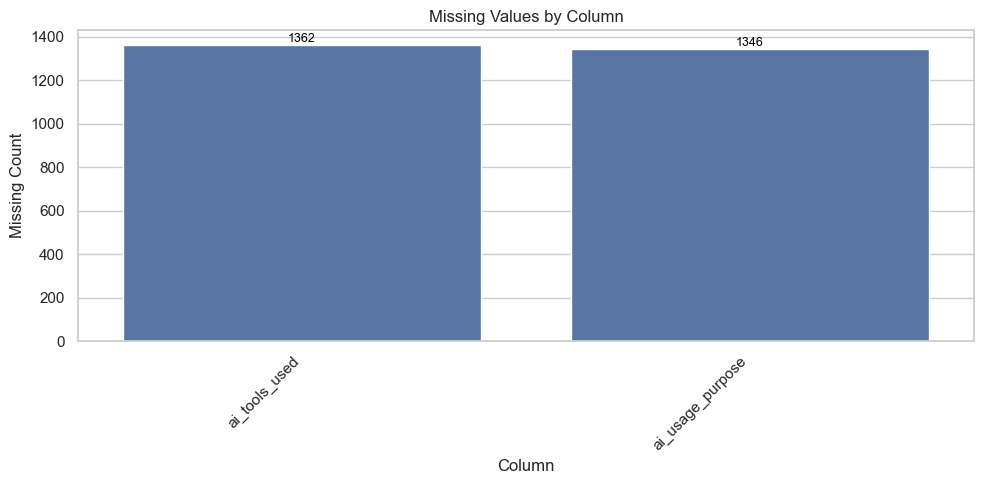

In [56]:

# -----------------------------
# 6.1 Missing values visualization | 缺失值可视化
# -----------------------------

missing_counts = df.isna().sum().sort_values(ascending=False)
missing_counts = missing_counts[missing_counts > 0]

if len(missing_counts) > 0:
    plt.figure(figsize=(10, 5))
    ax = sns.barplot(x=missing_counts.index, y=missing_counts.values, color="C0")

    # Add numeric labels on top of each bar
    for p in ax.patches:
        height = p.get_height()
        ax.text(
            p.get_x() + p.get_width() / 2,
            height + 0.5,
            f"{int(height)}",
            ha="center",
            va="bottom",
            fontsize=9,
            color="black",
        )

    plt.xticks(rotation=45, ha="right")
    plt.title("Missing Values by Column")
    plt.xlabel("Column")
    plt.ylabel("Missing Count")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")


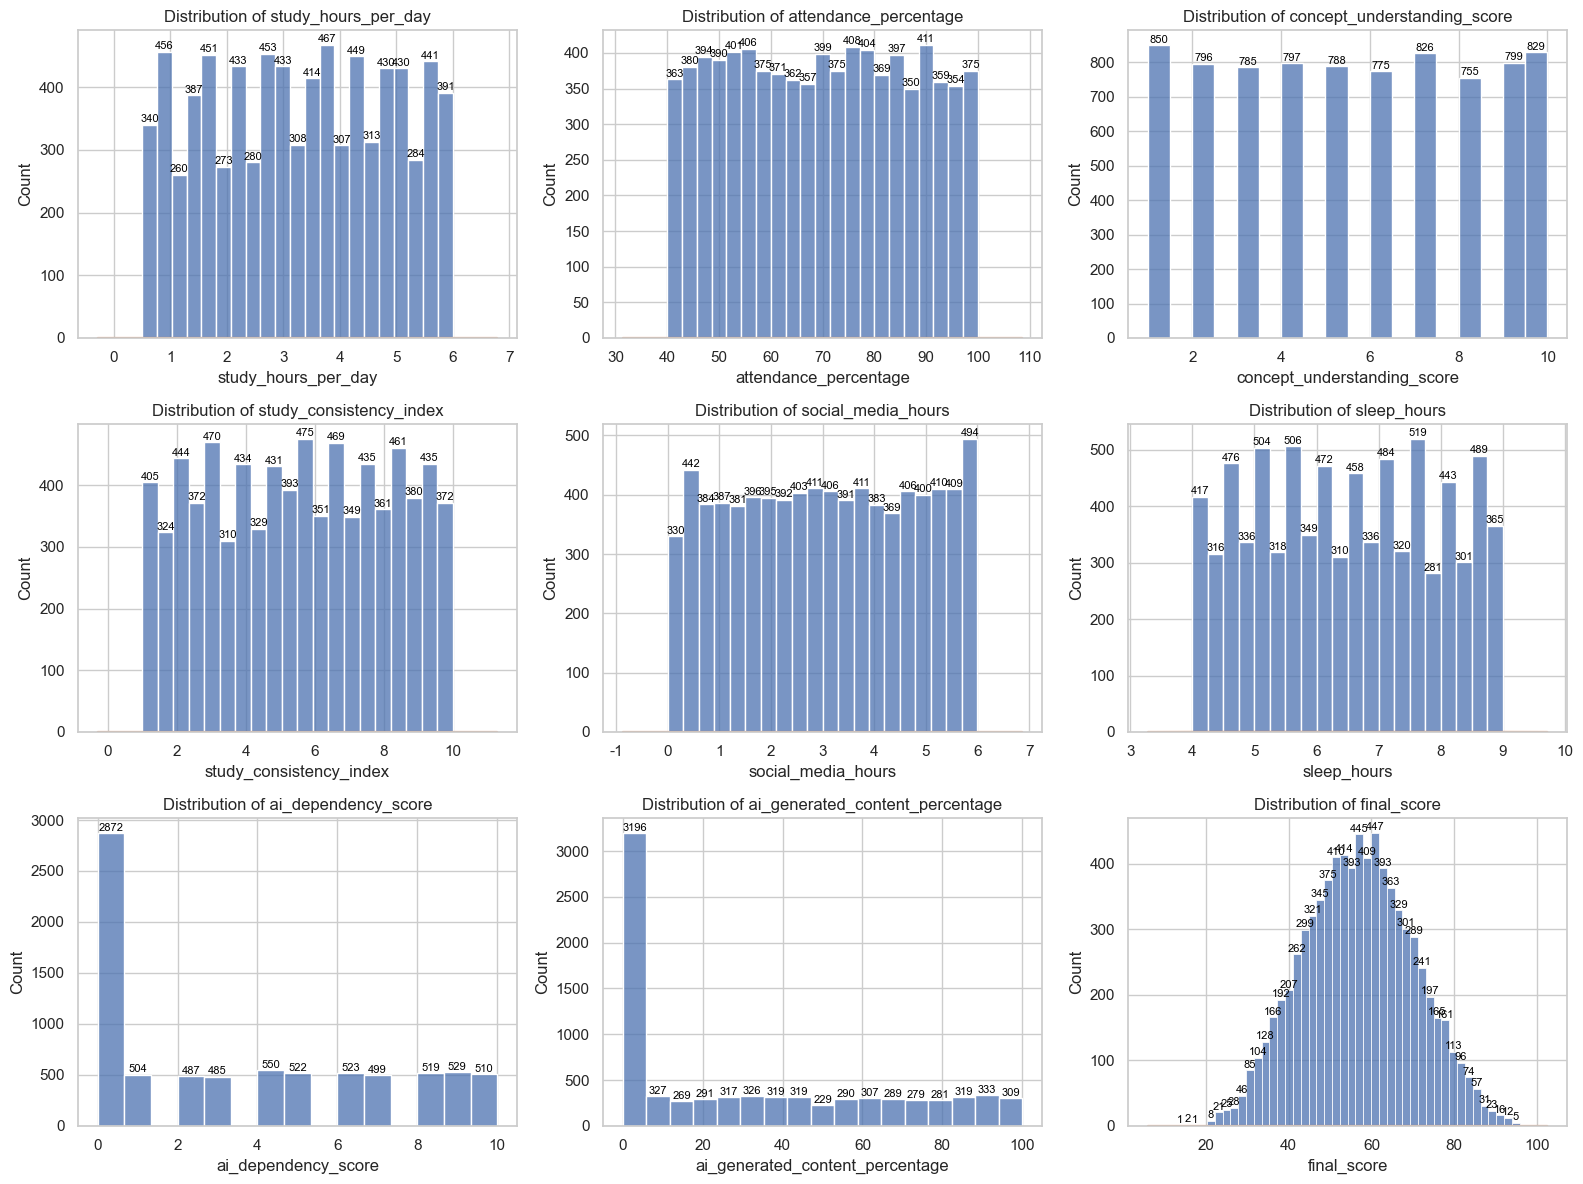

In [74]:

# -----------------------------
# 6.2 Distribution plots | 关键变量分布图
# -----------------------------

dist_cols = [
    "study_hours_per_day", "attendance_percentage", "concept_understanding_score",
    "study_consistency_index", "social_media_hours", "sleep_hours",
    "ai_dependency_score", "ai_generated_content_percentage", "final_score"
]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for ax, col in zip(axes, dist_cols):
    # Determine if the variable is effectively discrete (few unique values)
    vals = data[col].dropna()
    unique_vals = vals.unique()

    # Treat as discrete if all values are integer-like (even if stored as float)
    is_int_like = np.allclose(vals, np.round(vals)) if len(vals) > 0 else True

    # Only show KDE for numeric variables that are not integer-like and have enough unique values
    use_kde = (
        pd.api.types.is_numeric_dtype(data[col])
        and not is_int_like
        and len(unique_vals) > 30
    )

    sns.histplot(data[col], kde=False, ax=ax, color="C0")
    if use_kde:
        sns.kdeplot(data[col], ax=ax, color="C1")

    ax.set_title(f"Distribution of {col}")

    # Add bar value labels
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.text(
                p.get_x() + p.get_width() / 2,
                height + 1,
                f"{int(height)}",
                ha="center",
                va="bottom",
                fontsize=8,
                color="black",
            )

plt.tight_layout()
plt.show()


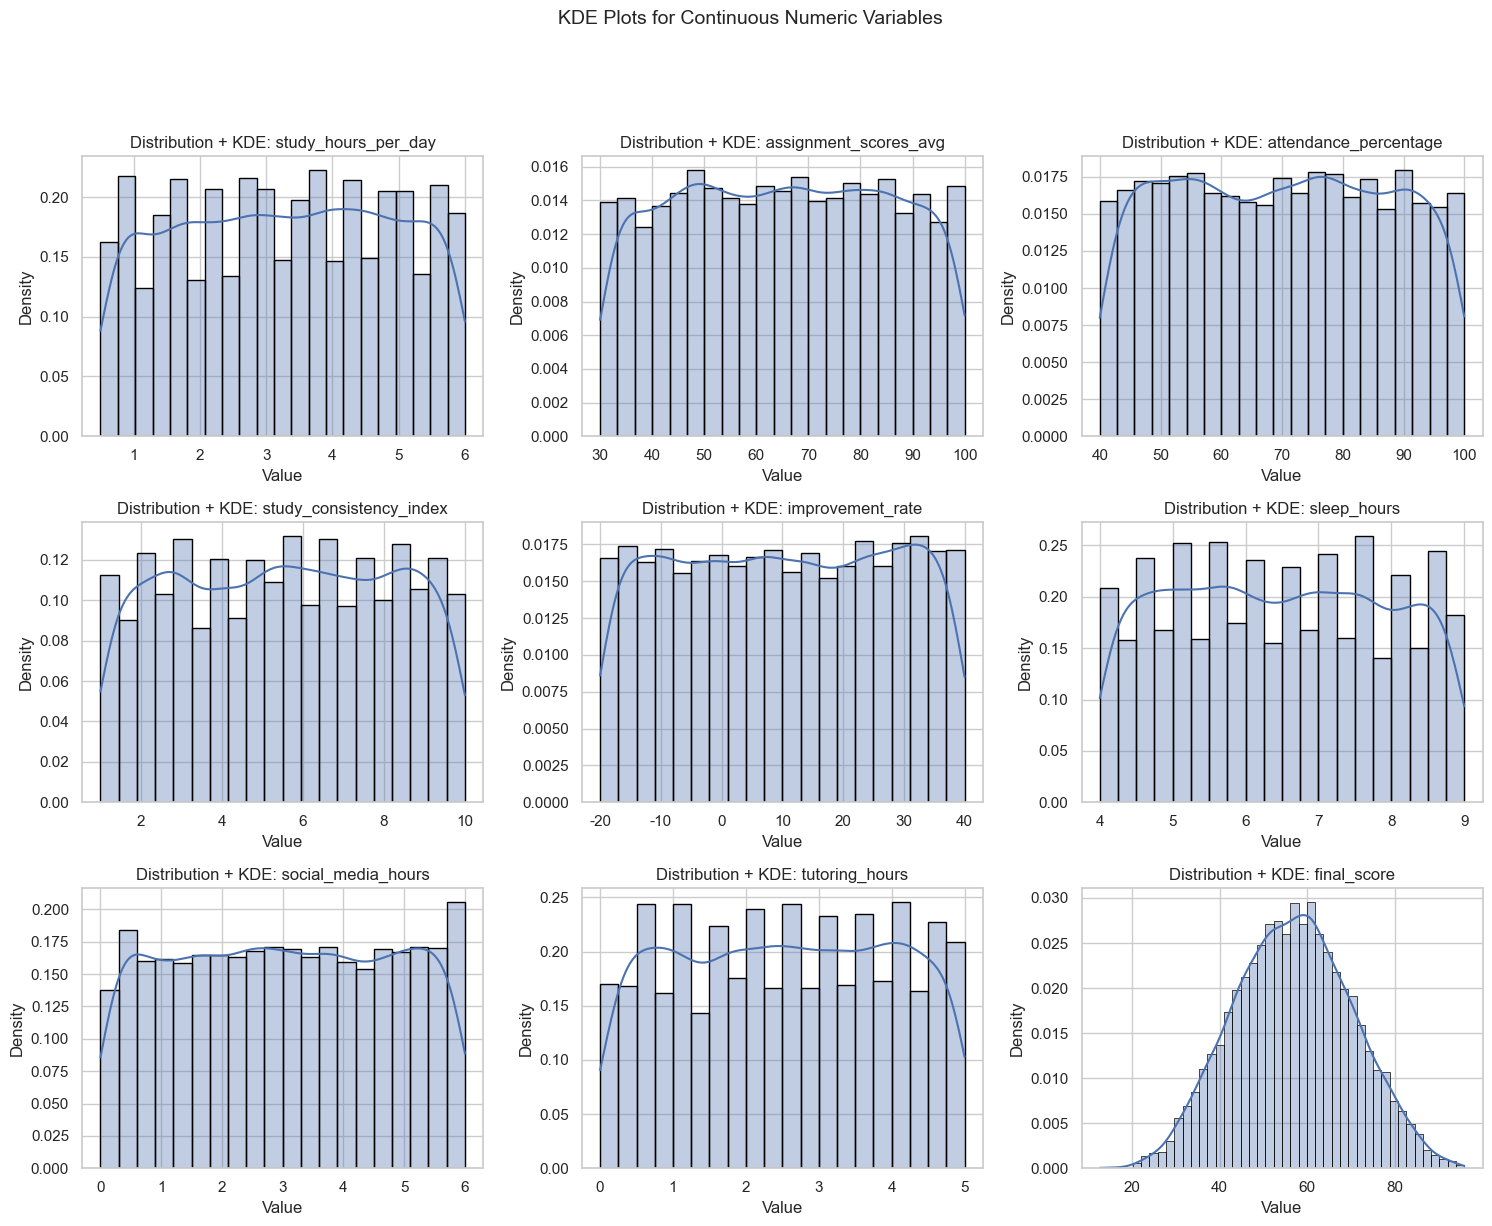

In [81]:
# -----------------------------
# 6.2.1 Continuous variable KDE grid | 连续变量 KDE 网格图
# -----------------------------

# Identify continuous numeric variables (non-integer-like) for KDE plots
numeric_cols = data.select_dtypes(include=np.number).columns.tolist()
continuous_cols = []
for col in numeric_cols:
    vals = data[col].dropna()
    if len(vals) == 0:
        continue

    # Treat as integer-like if all values are whole numbers
    is_int_like = np.allclose(vals, np.round(vals))
    if not is_int_like and vals.nunique() > 30:
        continuous_cols.append(col)

if len(continuous_cols) == 0:
    print("No continuous numeric columns found for KDE plots.")
else:
    # Fix the grid to 3x3 so layout is consistent
    max_plots = 9
    plot_cols = continuous_cols[:max_plots]

    fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12), squeeze=False)
    axes_flat = axes.flatten()

    for ax, col in zip(axes_flat, plot_cols):
        sns.histplot(
            data=data,
            x=col,
            kde=True,
            stat="density",
            ax=ax,
            color="C0",
            edgecolor="black",
            alpha=0.35,
            line_kws={"linewidth": 1.5, "color": "C1"},
        )
        ax.set_title(f"Distribution + KDE: {col}")
        ax.set_xlabel("Value")
        ax.set_ylabel("Density")

    # Disable any unused subplots
    for ax in axes_flat[len(plot_cols) :]:
        ax.axis("off")

    plt.suptitle("KDE Plots for Continuous Numeric Variables", y=1.02, fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

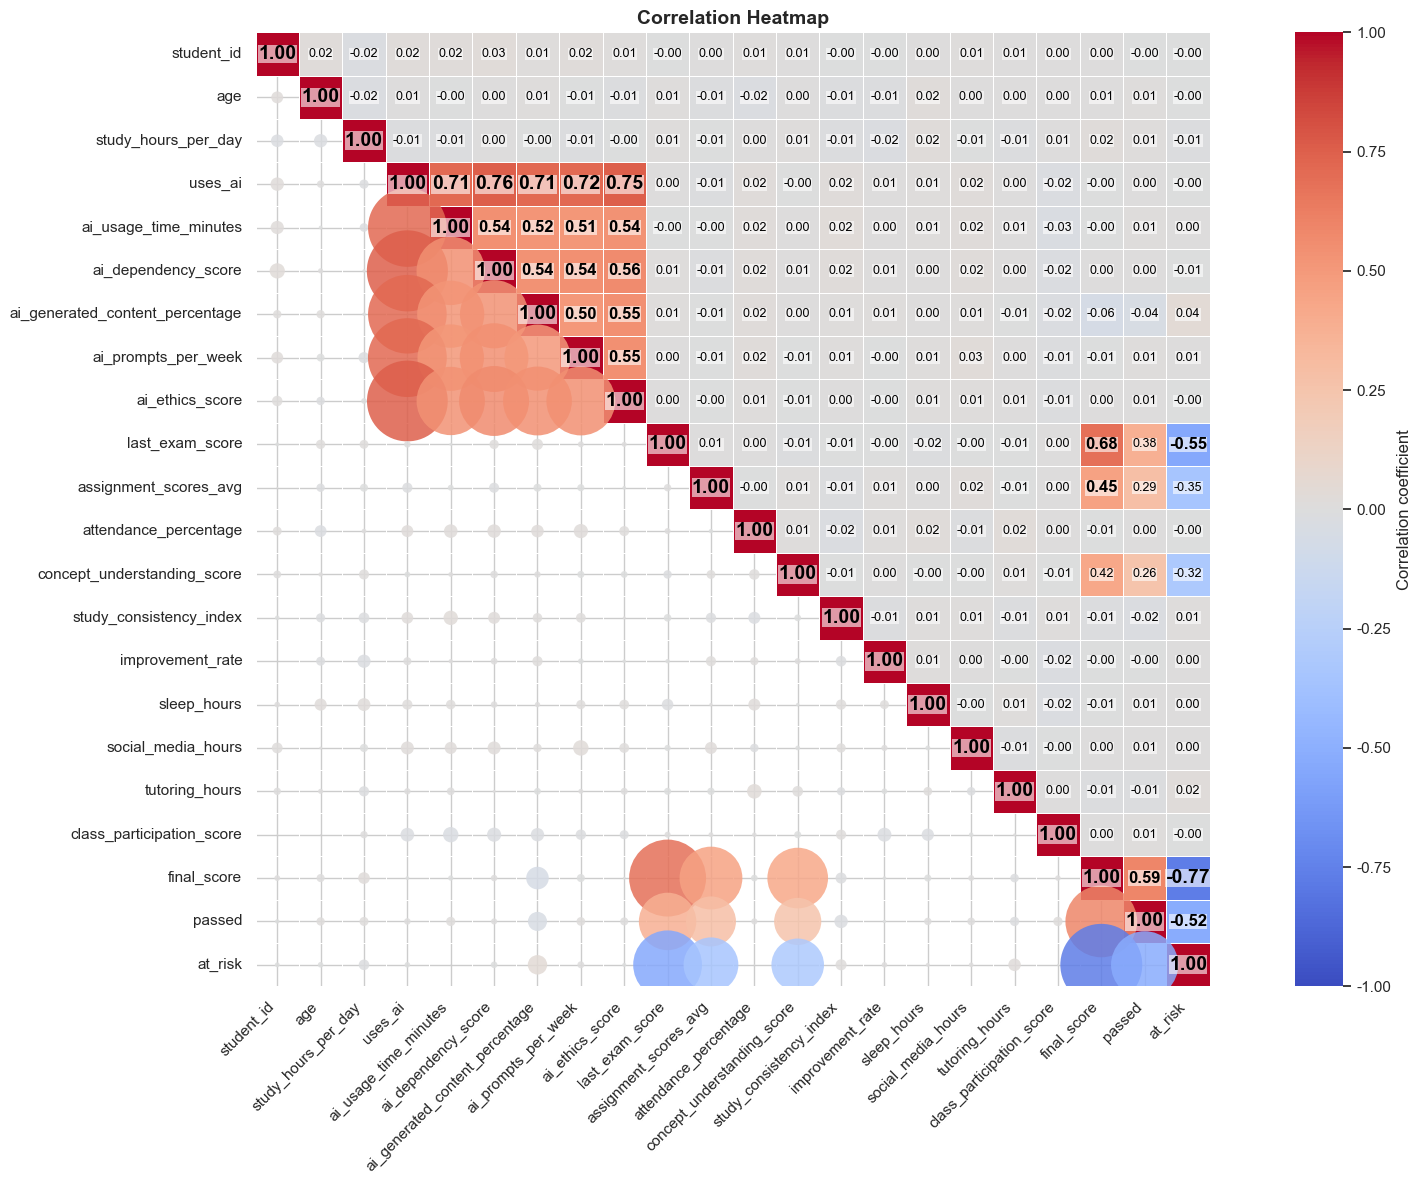

In [60]:
# -----------------------------
# 6.3 Correlation heatmap | 相关性热力图
# -----------------------------

numeric_cols = data.select_dtypes(include=np.number).columns.tolist()
corr_matrix = data[numeric_cols].corr()

# Split view: upper triangle shows numeric values (heatmap + text), lower triangle shows circle markers
mask_upper = np.tril(np.ones_like(corr_matrix, dtype=bool), k=-1)
mask_lower = np.triu(np.ones_like(corr_matrix, dtype=bool), k=0)

fig, ax = plt.subplots(figsize=(18, 12))

# Base heatmap for upper triangle numeric annotations
sns.heatmap(
    corr_matrix,
    mask=mask_upper,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    cbar_kws={"label": "Correlation coefficient"},
    square=True,
    linewidths=0.5,
    ax=ax,
    annot=False,
    cbar=True,
)

# Annotate values in the upper triangle (numeric labels only)
for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        if i > j:
            continue
        value = corr_matrix.iat[i, j]
        if np.abs(value) > 0.70:
            font_size = 14
            weight = "bold"
        elif np.abs(value) > 0.45:
            font_size = 12
            weight = "bold"
        else:
            font_size = 9
            weight = "normal"

        ax.text(
            j + 0.5,
            i + 0.5,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=font_size,
            fontweight=weight,
            color="black",
            zorder=3,
            bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.6, "pad": 0.3},
        )

# Overlay circle markers in the lower triangle (visual strength only, no text)
for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        if i <= j:
            continue
        value = corr_matrix.iat[i, j]
        size = np.abs(value) * 4500  # Adjust marker size for visibility
        ax.scatter(
            j + 0.5,
            i + 0.5,
            s=size,
            c=[value],
            cmap="coolwarm",
            vmin=-1,
            vmax=1,
            edgecolors="none",
            alpha=0.85,
            zorder=2,
        )

ax.set_xticks(np.arange(len(corr_matrix.columns)) + 0.5)
ax.set_yticks(np.arange(len(corr_matrix.columns)) + 0.5)
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(corr_matrix.columns, rotation=0)
ax.set_xlim(0, len(corr_matrix.columns))
ax.set_ylim(len(corr_matrix.columns), 0)

plt.title("Correlation Heatmap", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


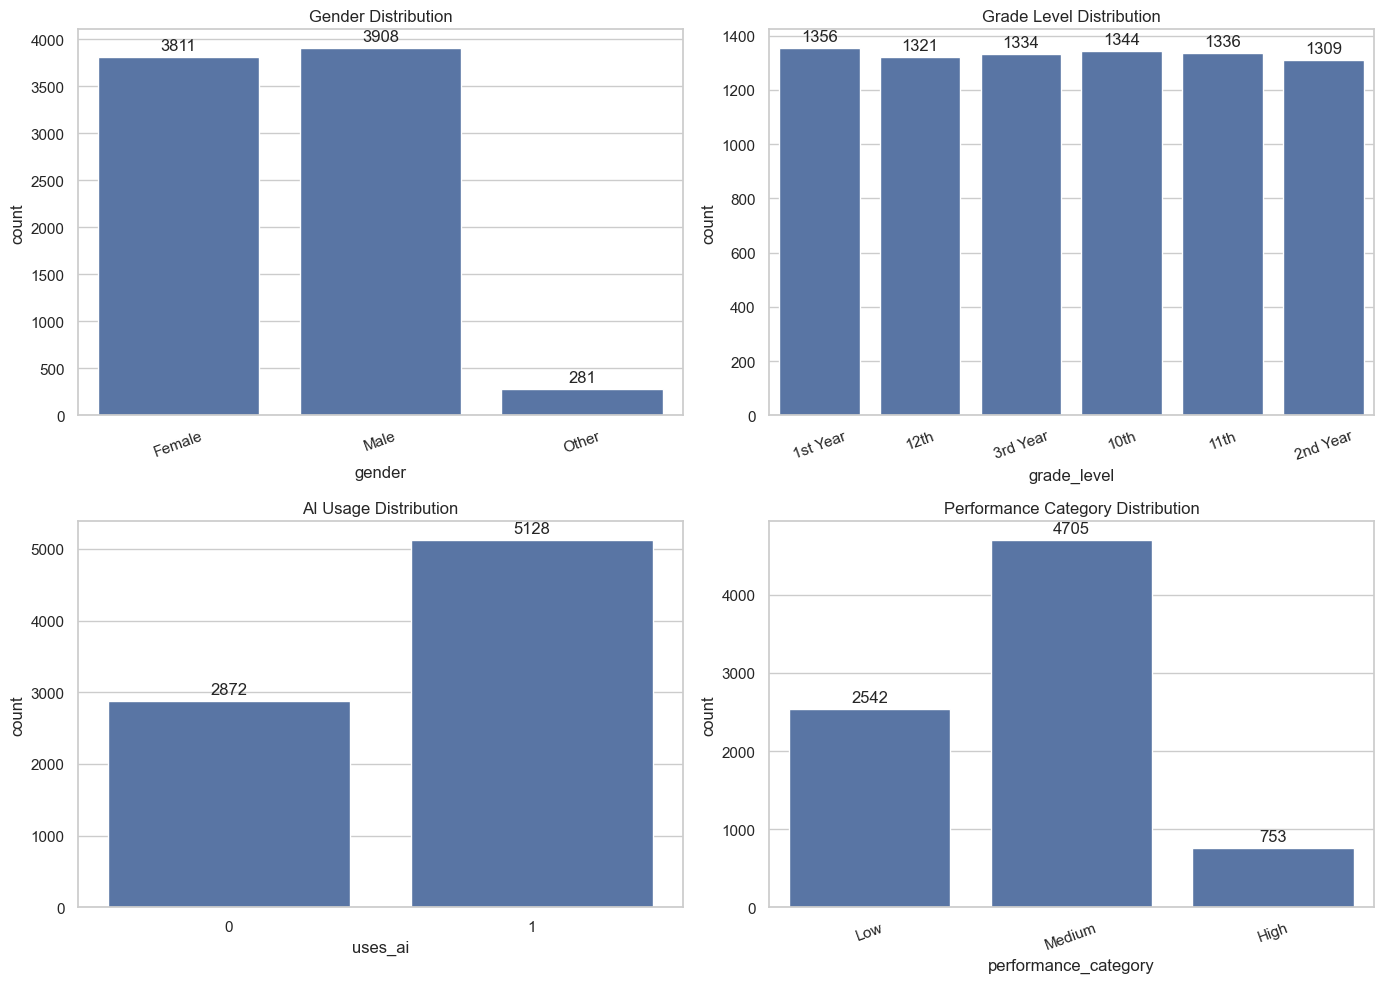

In [57]:

# -----------------------------
# 6.4 Count plots for categorical variables | 类别变量柱状分布图
# -----------------------------

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = sns.countplot(data=data, x="gender", ax=axes[0, 0], color="C0")
axes[0, 0].set_title("Gender Distribution")#性别分布
axes[0, 0].tick_params(axis='x', rotation=20)
ax.bar_label(ax.containers[0], fmt="%d", padding=3)

ax = sns.countplot(data=data, x="grade_level", ax=axes[0, 1], color="C0")
axes[0, 1].set_title("Grade Level Distribution")#年级分布
axes[0, 1].tick_params(axis='x', rotation=20)
ax.bar_label(ax.containers[0], fmt="%d", padding=3)

ax = sns.countplot(data=data, x="uses_ai", ax=axes[1, 0], color="C0")
axes[1, 0].set_title("AI Usage Distribution")#AI 使用情况分布
ax.bar_label(ax.containers[0], fmt="%d", padding=3)

ax = sns.countplot(data=data, x="performance_category", ax=axes[1, 1], color="C0")
axes[1, 1].set_title("Performance Category Distribution")#成绩等级分布
axes[1, 1].tick_params(axis='x', rotation=20)
ax.bar_label(ax.containers[0], fmt="%d", padding=3)

plt.tight_layout()
plt.show()


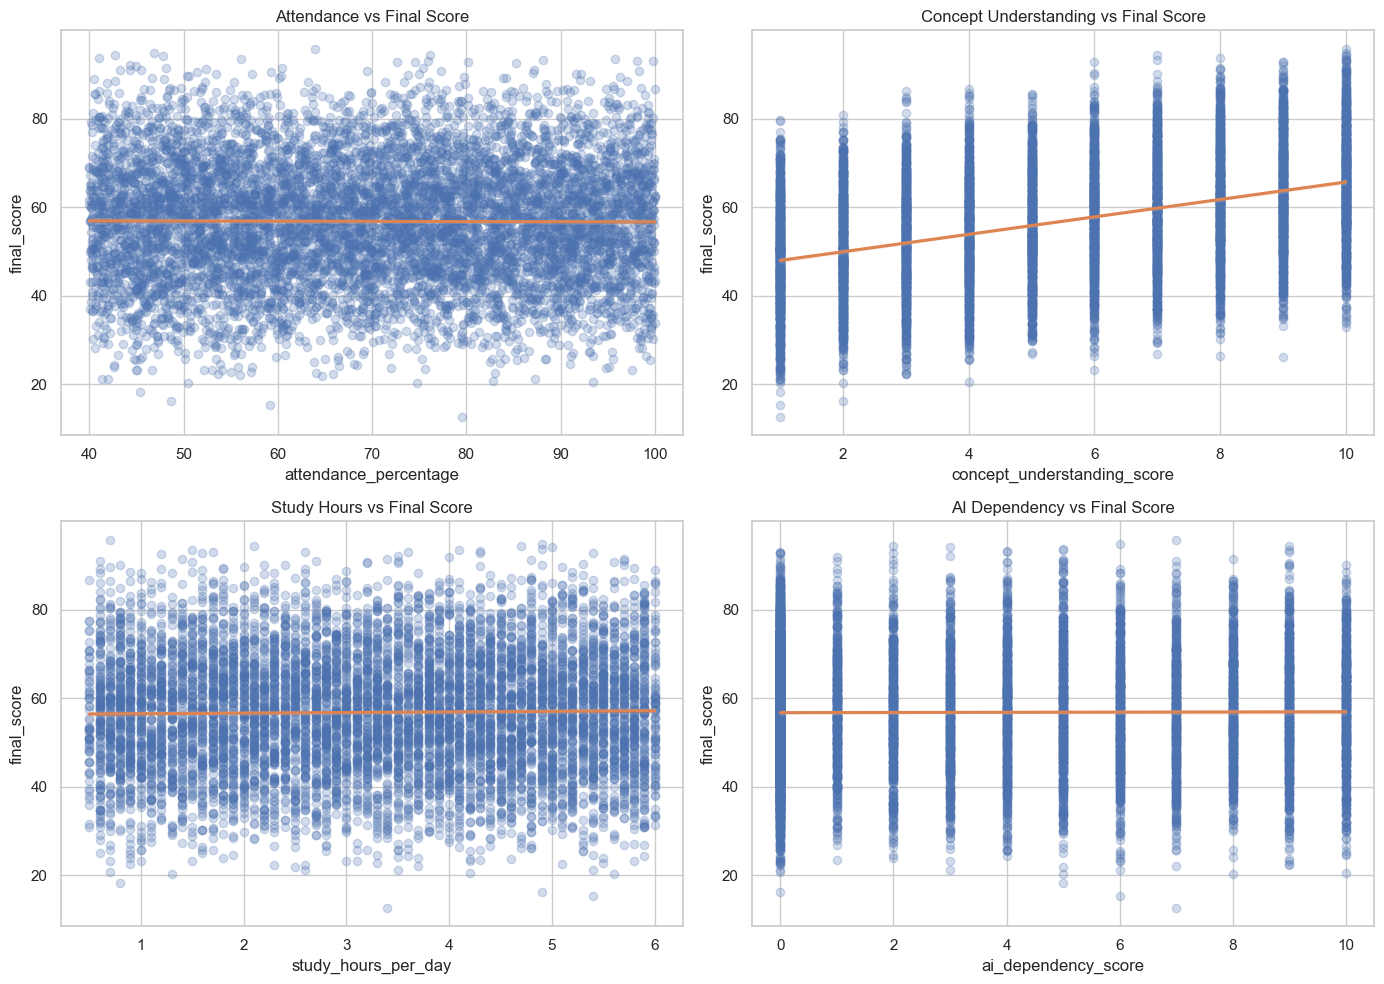

In [21]:

# -----------------------------
# 6.5 Scatter plots with trend lines | 带趋势线的散点图
# -----------------------------

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.regplot(data=data, x="attendance_percentage", y="final_score", scatter_kws={"alpha": 0.25}, line_kws={"color":"C1"}, ax=axes[0, 0])
axes[0, 0].set_title("Attendance vs Final Score")#出勤率与期末成绩

sns.regplot(data=data, x="concept_understanding_score", y="final_score", scatter_kws={"alpha": 0.25}, line_kws={"color":"C1"}, ax=axes[0, 1])
axes[0, 1].set_title("Concept Understanding vs Final Score")#概念理解与期末成绩

sns.regplot(data=data, x="study_hours_per_day", y="final_score", scatter_kws={"alpha": 0.25}, line_kws={"color":"C1"}, ax=axes[1, 0])
axes[1, 0].set_title("Study Hours vs Final Score")#学习时长与期末成绩

sns.regplot(data=data, x="ai_dependency_score", y="final_score", scatter_kws={"alpha": 0.25}, line_kws={"color":"C1"}, ax=axes[1, 1])
axes[1, 1].set_title("AI Dependency vs Final Score")#AI 依赖度与期末成绩

plt.tight_layout()
plt.show()


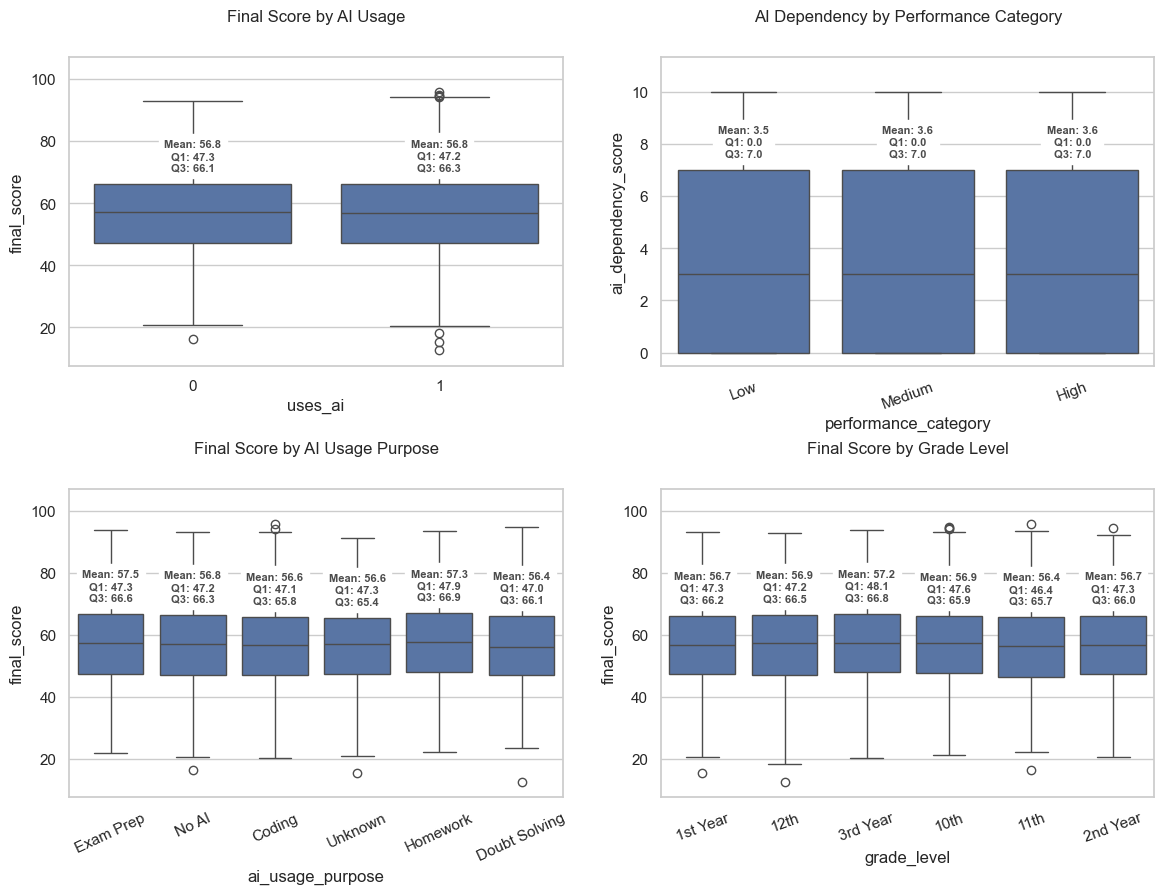

In [69]:

# -----------------------------
# 6.6 Box plots | 箱线图
# -----------------------------

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Helper to add mean / quartile annotations on boxplots
# The annotation is positioned near the top of each box (inside the axes), to avoid
# colliding with the subplot title and to keep the full box visible.
def annotate_boxplot_stats(ax, data, x, y):
    groups = data[x].unique()

    # Expand y-axis to leave room for annotations above the boxes
    y_min, y_max = ax.get_ylim()
    span = y_max - y_min
    data_max = data[y].max()
    target_max = max(y_max, data_max + span * 0.12)
    ax.set_ylim(y_min, target_max)

    # Place annotations just above each box (based on Q3), to avoid title overlap
    for group in groups:
        subset = data[data[x] == group][y].dropna()
        if subset.empty:
            continue

        q1 = subset.quantile(0.25)
        median = subset.quantile(0.50)
        q3 = subset.quantile(0.75)
        mean = subset.mean()

        # Find the x position for the group in the boxplot
        xpos = list(groups).index(group)

        # Place annotation above Q3 but keep it below the axis top boundary
        y_pos = min(q3 + span * 0.04, y_max - span * 0.06)

        ax.text(
            xpos,
            y_pos,
            f"Mean: {mean:.1f}\nQ1: {q1:.1f}\nQ3: {q3:.1f}",
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="bold",
            color="black",
            backgroundcolor="white",
            alpha=0.7,
        )


sns.boxplot(data=data, x="uses_ai", y="final_score", ax=axes[0, 0], color="C0")
axes[0, 0].set_title("Final Score by AI Usage", pad=26)#不同 AI 使用情况的成绩分布

# Ensure the full whiskers are visible (avoid clipping by auto-limits)
axes[0, 0].set_ylim(data["final_score"].min() - 5, data["final_score"].max() + 5)
annotate_boxplot_stats(axes[0, 0], data, "uses_ai", "final_score")

sns.boxplot(data=data, x="performance_category", y="ai_dependency_score", ax=axes[0, 1], color="C0")
axes[0, 1].set_title("AI Dependency by Performance Category", pad=26)#不同成绩等级的 AI 依赖度
axes[0, 1].tick_params(axis='x', rotation=20)
axes[0, 1].set_ylim(data["ai_dependency_score"].min() - 0.5, data["ai_dependency_score"].max() + 0.5)
annotate_boxplot_stats(axes[0, 1], data, "performance_category", "ai_dependency_score")

top_purposes = data["ai_usage_purpose"].value_counts().head(6).index
temp_box = data[data["ai_usage_purpose"].isin(top_purposes)].copy()
sns.boxplot(data=temp_box, x="ai_usage_purpose", y="final_score", ax=axes[1, 0], color="C0")
axes[1, 0].set_title("Final Score by AI Usage Purpose", pad=26)#不同 AI 使用目的的成绩分布
axes[1, 0].tick_params(axis='x', rotation=25)
axes[1, 0].set_ylim(data["final_score"].min() - 5, data["final_score"].max() + 5)
annotate_boxplot_stats(axes[1, 0], temp_box, "ai_usage_purpose", "final_score")

sns.boxplot(data=data, x="grade_level", y="final_score", ax=axes[1, 1], color="C0")
axes[1, 1].set_title("Final Score by Grade Level", pad=26)#不同年级的成绩分布
axes[1, 1].tick_params(axis='x', rotation=20)
axes[1, 1].set_ylim(data["final_score"].min() - 5, data["final_score"].max() + 5)
annotate_boxplot_stats(axes[1, 1], data, "grade_level", "final_score")

fig.subplots_adjust(top=0.86, bottom=0.12, hspace=0.40)
plt.show()


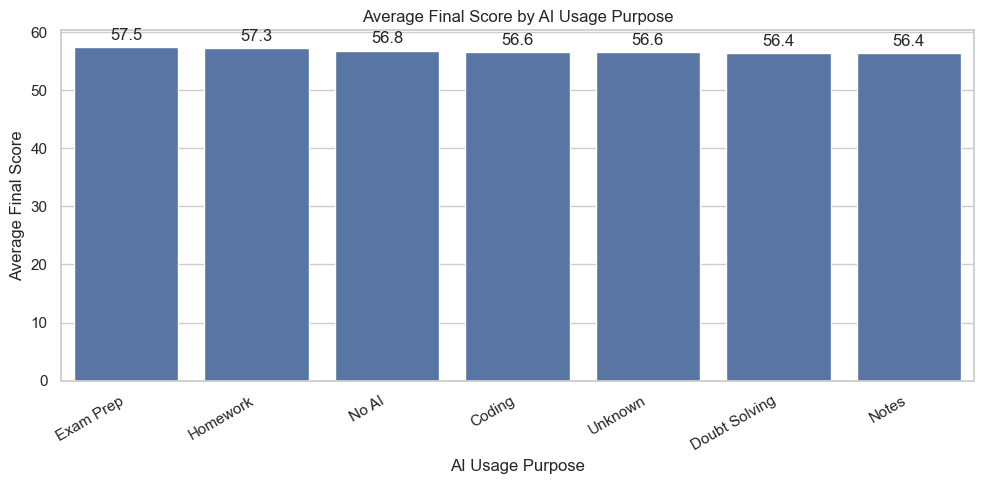

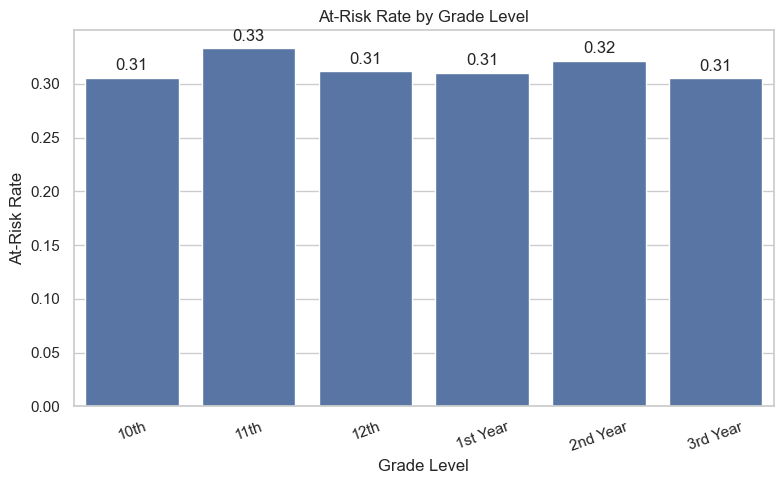

In [70]:

# -----------------------------
# 6.7 Aggregated bar charts | 汇总柱状图
# -----------------------------

# Average final score by AI usage purpose | 不同 AI 使用目的的平均成绩
purpose_score = (
    data.groupby("ai_usage_purpose", as_index=False)["final_score"]
    .mean()
    .sort_values("final_score", ascending=False)
)

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=purpose_score, x="ai_usage_purpose", y="final_score", color="C0")
plt.title("Average Final Score by AI Usage Purpose")#不同 AI 使用目的的平均成绩
plt.xlabel("AI Usage Purpose")#不同 AI 使用目的
plt.ylabel("Average Final Score")#平均成绩
plt.xticks(rotation=30, ha="right")

# Add value labels
ax.bar_label(ax.containers[0], fmt="%.1f", padding=3)

plt.tight_layout()
plt.show()

# At-risk rate by grade level | 不同年级的高风险比例
risk_by_grade = data.groupby("grade_level", as_index=False)["at_risk"].mean()

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=risk_by_grade, x="grade_level", y="at_risk", color="C0")
plt.title("At-Risk Rate by Grade Level")#不同年级的高风险比例
plt.xlabel("Grade Level")#年级
plt.ylabel("At-Risk Rate")#高风险比例
plt.xticks(rotation=20)

# Add value labels
ax.bar_label(ax.containers[0], fmt="%.2f", padding=3)

plt.tight_layout()
plt.show()



## 7. Facet Chart analysis (Category A) | 分面图分析（A 类方法）

Facet charts are one of the required Category A methods.  
分面图是课程要求中的 A 类方法之一。

They are useful for communicating segmented patterns to a management audience.  
它们非常适合向管理层展示分组差异和结构性特征。


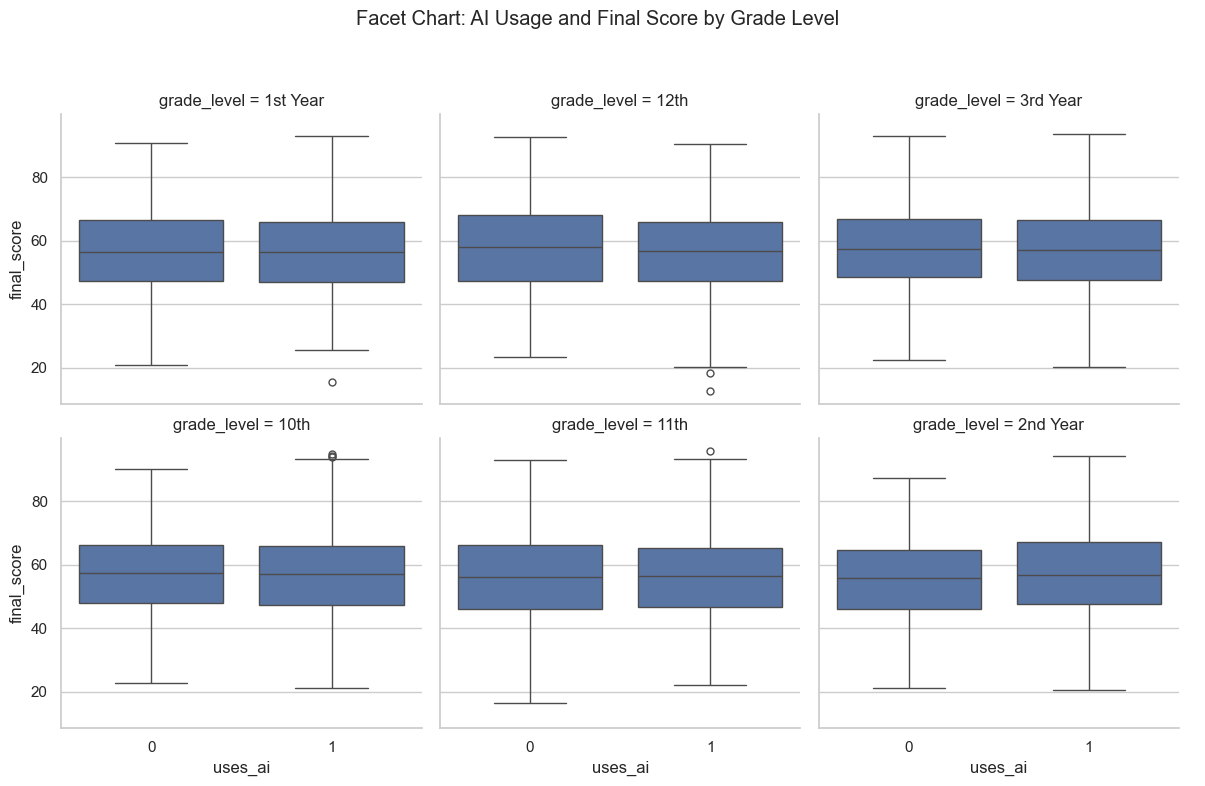

In [24]:

# -----------------------------
# 7.1 Facet chart: AI usage vs final score by grade level
# 7.1 分面图：不同年级中 AI 使用与成绩的关系
# -----------------------------

g = sns.catplot(
    data=data,
    x="uses_ai",
    y="final_score",
    col="grade_level",
    kind="box",
    color="C0",
    col_wrap=3,
    sharey=True,
    height=4
)
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("Facet Chart: AI Usage and Final Score by Grade Level")#不同年级中 AI 使用与成绩的关系
plt.show()


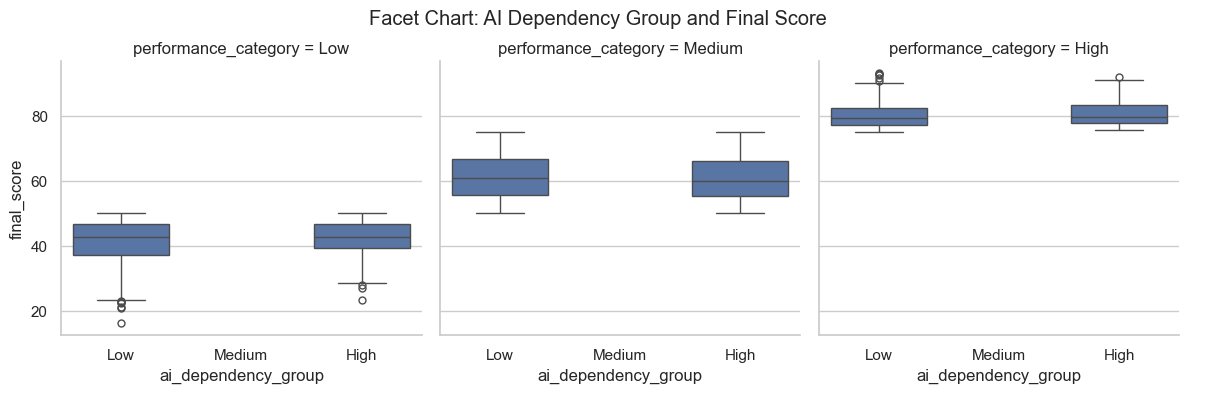

In [30]:

# -----------------------------
# 7.2 Facet chart: AI dependency and final score by performance category
# 7.2 分面图：不同成绩等级中 AI 依赖度与成绩关系
# -----------------------------

# Convert AI dependency score into groups for easier visualization | 将 AI 依赖度分组，便于可视化
data["ai_dependency_group"] = pd.cut(
    data["ai_dependency_score"],
    bins=[-0.01, 0.33, 0.66, 1.0],
    labels=["Low", "Medium", "High"]
)

g = sns.catplot(
    data=data,
    x="ai_dependency_group",
    y="final_score",
    col="performance_category",
    kind="box",
    color="C0",
    col_wrap=3,
    sharey=True,
    height=4
)
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("Facet Chart: AI Dependency Group and Final Score")#不同成绩等级中 AI 依赖度与成绩关系
plt.show()


In [31]:
# Check performance_category values / 检查成绩等级的实际值
print("Unique performance_category values | 性能类别唯一值:")
print(data["performance_category"].unique())
print("\nperformance_category value counts | 性能类别计数:")
print(data["performance_category"].value_counts(dropna=False))


Unique performance_category values | 性能类别唯一值:
['Low' 'Medium' 'High']

performance_category value counts | 性能类别计数:
performance_category
Medium    4705
Low       2542
High       753
Name: count, dtype: int64



## 8. Modeling preparation | 建模准备

We separate explanatory modeling (`final_score`) from intervention-oriented classification (`at_risk`).  
我们将解释型建模（`final_score`）与干预导向分类（`at_risk`）分开处理。


In [32]:

# -----------------------------
# 8. Prepare feature lists | 准备变量列表
# -----------------------------

target_reg = "final_score"
target_clf = "at_risk"

# Drop helper / leakage columns from features | 删除辅助字段及潜在泄露变量
drop_cols = [
    "student_id", "final_score", "at_risk", "passed", "performance_category", "ai_dependency_group"
]
feature_cols = [col for col in data.columns if col not in drop_cols]

X = data[feature_cols]
y_reg = data[target_reg]
y_clf = data[target_clf]

# Identify numeric and categorical columns | 区分数值变量与类别变量
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Number of features | 特征数:", len(feature_cols))
print("Numeric features | 数值变量:", numeric_features)
print("Categorical features | 类别变量:", categorical_features)


Number of features | 特征数: 22
Numeric features | 数值变量: ['age', 'study_hours_per_day', 'uses_ai', 'ai_usage_time_minutes', 'ai_dependency_score', 'ai_generated_content_percentage', 'ai_prompts_per_week', 'ai_ethics_score', 'last_exam_score', 'assignment_scores_avg', 'attendance_percentage', 'concept_understanding_score', 'study_consistency_index', 'improvement_rate', 'sleep_hours', 'social_media_hours', 'tutoring_hours', 'class_participation_score']
Categorical features | 类别变量: ['gender', 'grade_level', 'ai_tools_used', 'ai_usage_purpose']



## 9. Linear Regression (Category A) | 线性回归（A 类方法）

This model explains which variables are associated with higher or lower final scores.  
该模型用于解释哪些变量与更高或更低的期末成绩相关。


In [33]:

# -----------------------------
# 9.1 Train-test split for regression | 回归任务训练测试集划分
# -----------------------------

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

# Preprocess: median for numeric, most frequent for categorical | 预处理：数值变量中位数填充，类别变量众数填充
preprocessor_reg = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)
    ]
)

# Build regression pipeline | 构建线性回归流水线
linreg_model = Pipeline(steps=[
    ("preprocessor", preprocessor_reg),
    ("model", LinearRegression())
])

linreg_model.fit(X_train_reg, y_train_reg)
y_pred_reg = linreg_model.predict(X_test_reg)

# Evaluation metrics | 评估指标
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2 = r2_score(y_test_reg, y_pred_reg)

print(f"Linear Regression RMSE | 线性回归 RMSE: {rmse:.4f}")
print(f"Linear Regression R^2 | 线性回归 R^2: {r2:.4f}")


Linear Regression RMSE | 线性回归 RMSE: 4.9682
Linear Regression R^2 | 线性回归 R^2: 0.8673


In [34]:

# -----------------------------
# 9.2 Cross-validation for regression | 回归交叉验证
# -----------------------------

cv_reg = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2_scores = cross_val_score(linreg_model, X, y_reg, cv=cv_reg, scoring="r2")

print("Cross-validated R^2 scores | 交叉验证 R^2 分数:")
print(cv_r2_scores)
print(f"Mean CV R^2 | 平均交叉验证 R^2: {cv_r2_scores.mean():.4f}")


Cross-validated R^2 scores | 交叉验证 R^2 分数:
[0.86727501 0.84770891 0.85614789 0.86215893 0.84990929]
Mean CV R^2 | 平均交叉验证 R^2: 0.8566


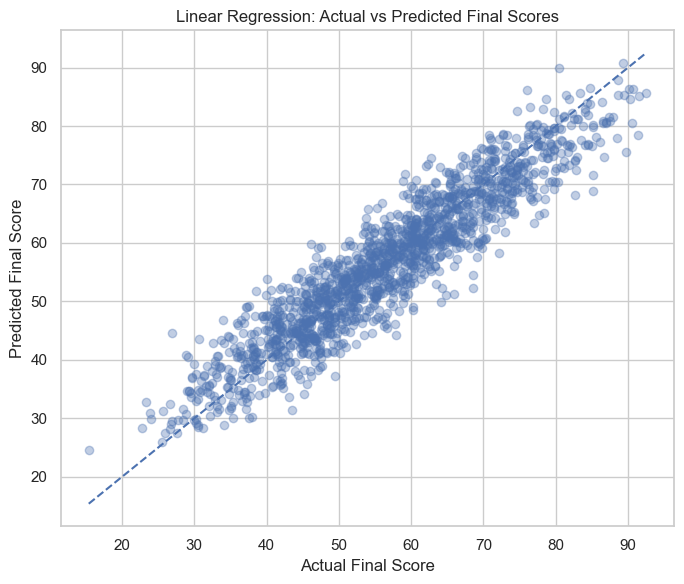

In [36]:

# -----------------------------
# 9.3 Predicted vs actual plot | 预测值与真实值对比图
# -----------------------------

plt.figure(figsize=(7, 6))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.35)
plt.xlabel("Actual Final Score")#真实成绩
plt.ylabel("Predicted Final Score")#预测成绩
plt.title("Linear Regression: Actual vs Predicted Final Scores")#线性回归：真实成绩与预测成绩对比

# Reference line | 参考线
min_val = min(y_test_reg.min(), y_pred_reg.min())
max_val = max(y_test_reg.max(), y_pred_reg.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.tight_layout()
plt.show()


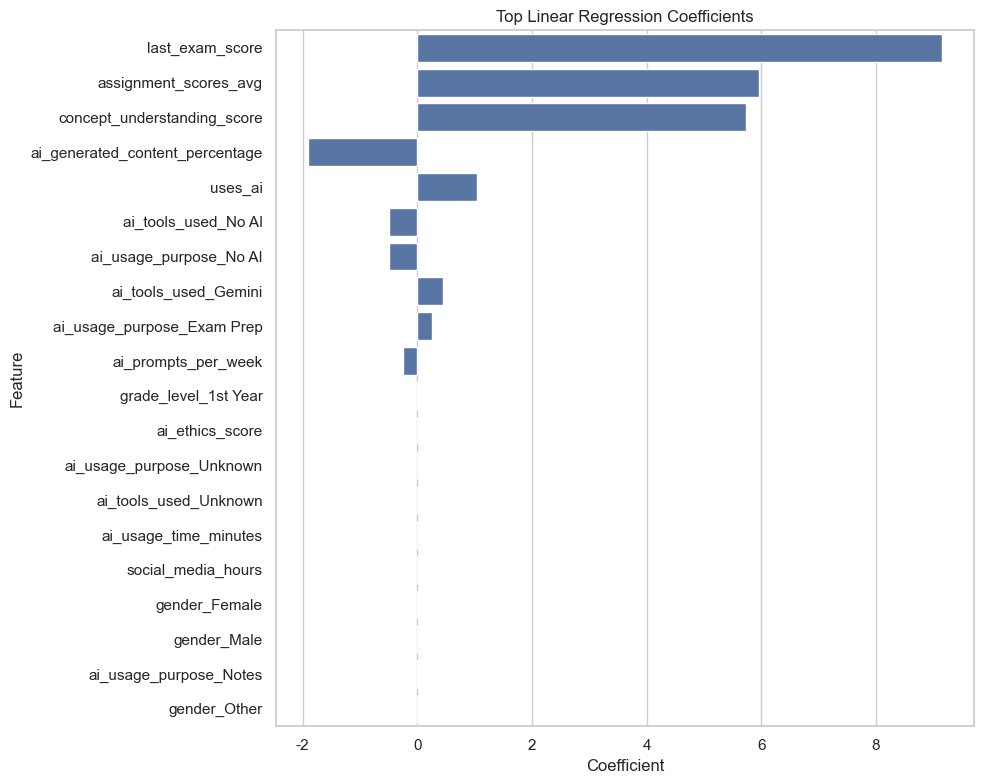

,feature,coefficient
8,last_exam_score,9.155131
9,assignment_scores_avg,5.966289
11,concept_understanding_score,5.726316
5,ai_generated_content_percentage,-1.909966
2,uses_ai,1.046133
32,ai_tools_used_No AI,-0.501760
38,ai_usage_purpose_No AI,-0.501760
31,ai_tools_used_Gemini,0.450990
36,ai_usage_purpose_Exam Prep,0.252423
6,ai_prompts_per_week,-0.247329


In [37]:

# -----------------------------
# 9.4 Top coefficients plot | 关键系数可视化
# -----------------------------

# Retrieve transformed feature names | 获取转换后的特征名称
ohe = linreg_model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
encoded_cat_names = ohe.get_feature_names_out(categorical_features).tolist()
all_feature_names = numeric_features + encoded_cat_names

coefficients = linreg_model.named_steps["model"].coef_
coef_df = pd.DataFrame({
    "feature": all_feature_names,
    "coefficient": coefficients
}).sort_values("coefficient", key=np.abs, ascending=False)

top_coef = pd.concat([coef_df.head(10), coef_df.tail(10)])

plt.figure(figsize=(10, 8))
sns.barplot(data=top_coef, x="coefficient", y="feature", color="C0")
plt.title("Top Linear Regression Coefficients")#线性回归关键系数
plt.xlabel("Coefficient")#系数
plt.ylabel("Feature")#特征
plt.tight_layout()
plt.show()

display(coef_df.head(15))



## 10. Logistic Regression (Category A) | 逻辑回归（A 类方法）

This model predicts whether a student belongs to the `at_risk` group.  
该模型用于预测学生是否属于 `at_risk` 高风险群体。


In [38]:

# -----------------------------
# 10.1 Train-test split for classification | 分类任务训练测试集划分
# -----------------------------

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

preprocessor_clf = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)
    ]
)

logreg_model = Pipeline(steps=[
    ("preprocessor", preprocessor_clf),
    ("model", LogisticRegression(max_iter=2000))
])

logreg_model.fit(X_train_clf, y_train_clf)
y_pred_clf = logreg_model.predict(X_test_clf)
y_prob_clf = logreg_model.predict_proba(X_test_clf)[:, 1]

print("Classification report | 分类报告:")
print(classification_report(y_test_clf, y_pred_clf))


Classification report | 分类报告:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92      1097
           1       0.83      0.83      0.83       503

    accuracy                           0.89      1600
   macro avg       0.87      0.87      0.87      1600
weighted avg       0.89      0.89      0.89      1600



In [39]:

# -----------------------------
# 10.2 Classification metrics | 分类模型评估指标
# -----------------------------

acc = accuracy_score(y_test_clf, y_pred_clf)
prec = precision_score(y_test_clf, y_pred_clf)
rec = recall_score(y_test_clf, y_pred_clf)
f1 = f1_score(y_test_clf, y_pred_clf)
auc_score = roc_auc_score(y_test_clf, y_prob_clf)

print(f"Accuracy | 准确率: {acc:.4f}")
print(f"Precision | 精确率: {prec:.4f}")
print(f"Recall | 召回率: {rec:.4f}")
print(f"F1-score | F1 分数: {f1:.4f}")
print(f"ROC-AUC | ROC 曲线下面积: {auc_score:.4f}")


Accuracy | 准确率: 0.8912
Precision | 精确率: 0.8257
Recall | 召回率: 0.8290
F1-score | F1 分数: 0.8274
ROC-AUC | ROC 曲线下面积: 0.9602


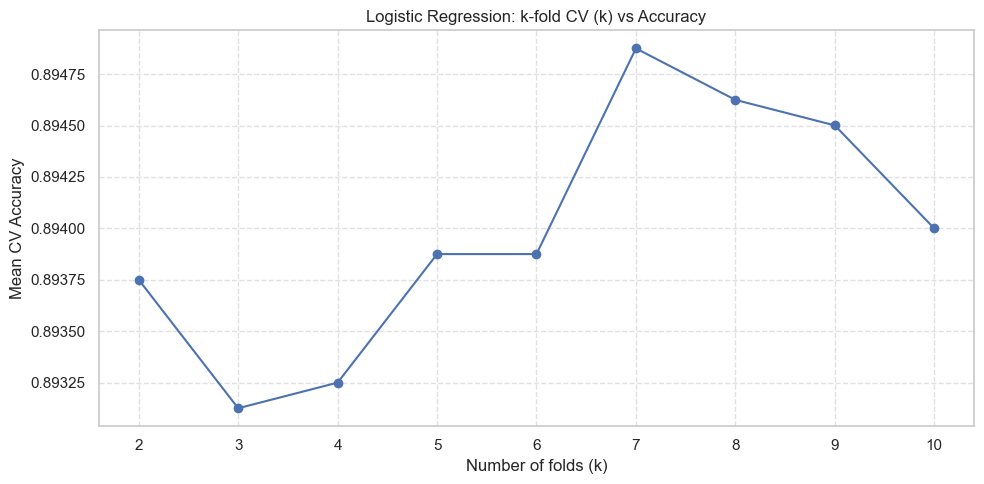

In [49]:
# -----------------------------
# 10.3 Logistic Regression: k-fold CV sweep (k folds vs accuracy)
# 10.3 逻辑回归 k 折交叉验证（k 值 vs 准确率）
# -----------------------------

# 使用已有的逻辑回归模型（包含预处理流水线），观察不同 k 值的交叉验证平均准确率变化。
# 这样可以在不新增其他模型的前提下，得到类似 k 值 vs 准确率的可视化分析。

k_values = list(range(2, 11))  # 尝试 2 到 10 折交叉验证
cv_mean_acc = []

for k in k_values:
    cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    scores = cross_val_score(logreg_model, X, y_clf, cv=cv, scoring="accuracy")
    cv_mean_acc.append(scores.mean())

plt.figure(figsize=(10, 5))
plt.plot(k_values, cv_mean_acc, marker='o')
plt.title('Logistic Regression: k-fold CV (k) vs Accuracy')
plt.xlabel('Number of folds (k)')
plt.ylabel('Mean CV Accuracy')
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


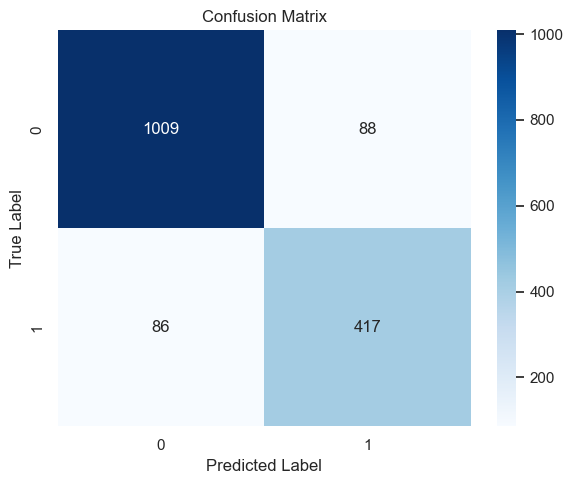

In [41]:

# -----------------------------
# 10.3 Confusion matrix | 混淆矩阵
# -----------------------------

cm = confusion_matrix(y_test_clf, y_pred_clf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")#混淆矩阵
plt.xlabel("Predicted Label")#预测标签
plt.ylabel("True Label")#真实标签
plt.tight_layout()
plt.show()


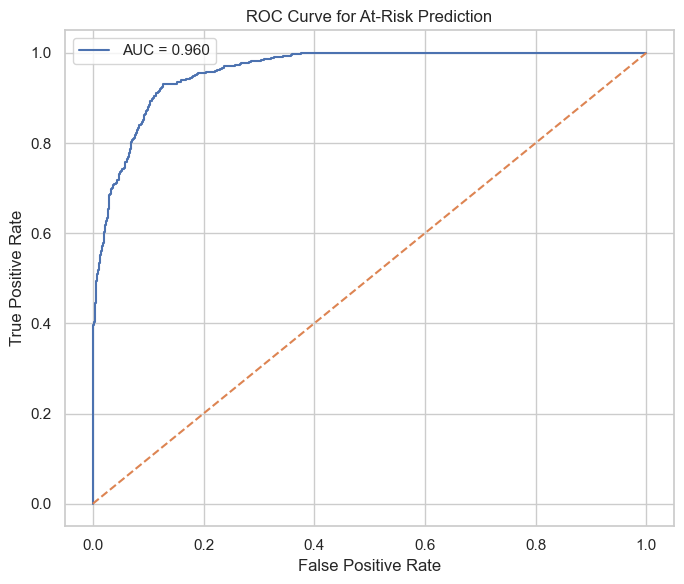

In [42]:

# -----------------------------
# 10.4 ROC curve | ROC 曲线
# -----------------------------

fpr, tpr, _ = roc_curve(y_test_clf, y_prob_clf)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")#假阳性率
plt.ylabel("True Positive Rate")#真阳性率
plt.title("ROC Curve for At-Risk Prediction")#高风险学生预测 ROC 曲线
plt.legend()
plt.tight_layout()
plt.show()


In [43]:

# -----------------------------
# 10.5 Cross-validation for logistic regression | 逻辑回归交叉验证
# -----------------------------

cv_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc_scores = cross_val_score(logreg_model, X, y_clf, cv=cv_clf, scoring="roc_auc")

print("Cross-validated ROC-AUC scores | 交叉验证 ROC-AUC 分数:")
print(cv_auc_scores)
print(f"Mean CV ROC-AUC | 平均交叉验证 ROC-AUC: {cv_auc_scores.mean():.4f}")


Cross-validated ROC-AUC scores | 交叉验证 ROC-AUC 分数:
[0.95426913 0.96416623 0.96060646 0.95824144 0.96584939]
Mean CV ROC-AUC | 平均交叉验证 ROC-AUC: 0.9606


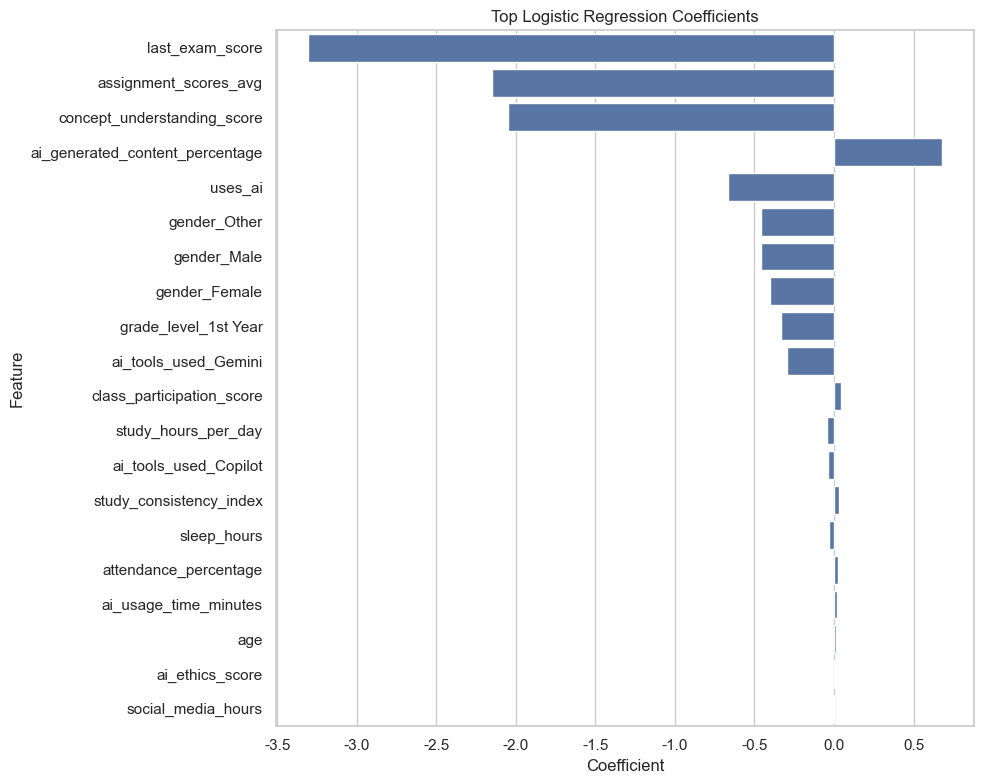

,feature,coefficient
8,last_exam_score,-3.307614
9,assignment_scores_avg,-2.146856
11,concept_understanding_score,-2.048866
5,ai_generated_content_percentage,0.680738
2,uses_ai,-0.664079
20,gender_Other,-0.459497
19,gender_Male,-0.458634
18,gender_Female,-0.403046
24,grade_level_1st Year,-0.333998
31,ai_tools_used_Gemini,-0.297527


In [45]:

# -----------------------------
# 10.6 Top odds-ratio style coefficient plot | 逻辑回归关键系数可视化
# -----------------------------

ohe_clf = logreg_model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
encoded_cat_names_clf = ohe_clf.get_feature_names_out(categorical_features).tolist()
all_feature_names_clf = numeric_features + encoded_cat_names_clf

log_coefs = logreg_model.named_steps["model"].coef_[0]
log_coef_df = pd.DataFrame({
    "feature": all_feature_names_clf,
    "coefficient": log_coefs
}).sort_values("coefficient", key=np.abs, ascending=False)

top_log_coef = pd.concat([log_coef_df.head(10), log_coef_df.tail(10)])

plt.figure(figsize=(10, 8))
sns.barplot(data=top_log_coef, x="coefficient", y="feature", color="C0")
plt.title("Top Logistic Regression Coefficients")#逻辑回归关键系数
plt.xlabel("Coefficient")#系数
plt.ylabel("Feature")#特征
plt.tight_layout()
plt.show()

display(log_coef_df.head(15))



## 11. Lasso Regression (Category B) | Lasso 回归（B 类方法）

Lasso is used as the required complementary Category B method.  
Lasso 用作课程要求中的补充 B 类方法。

Its main purpose is feature selection: less important variables are shrunk toward zero.  
其核心作用是变量筛选：不重要变量的系数会被压缩到接近 0。


In [46]:

# -----------------------------
# 11.1 Prepare data for Lasso | 为 Lasso 准备数据
# -----------------------------

# Use one-hot encoding first, then fit LassoCV | 先做哑变量编码，再拟合 LassoCV
X_lasso = pd.get_dummies(X, drop_first=True)

# Missing value handling | 缺失值处理
X_lasso = X_lasso.fillna(X_lasso.median(numeric_only=True))

# Scale features because Lasso is scale-sensitive | 由于 Lasso 对量纲敏感，需要标准化
scaler = StandardScaler()
X_lasso_scaled = scaler.fit_transform(X_lasso)

lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_lasso_scaled, y_reg)

lasso_coef = pd.Series(lasso.coef_, index=X_lasso.columns)
selected_features = lasso_coef[lasso_coef != 0].sort_values(key=np.abs, ascending=False)

print(f"Optimal alpha | 最优 alpha: {lasso.alpha_:.6f}")
print(f"Number of selected features | 选中的特征数量: {selected_features.shape[0]}")
display(selected_features.head(20).to_frame("coefficient"))


Optimal alpha | 最优 alpha: 0.028010
Number of selected features | 选中的特征数量: 23


,coefficient
last_exam_score,9.169709
assignment_scores_avg,5.982054
concept_understanding_score,5.709917
ai_generated_content_percentage,-1.781051
ai_tools_used_No AI,-1.244425
attendance_percentage,-0.126267
ai_prompts_per_week,-0.100995
study_hours_per_day,0.088055
ai_tools_used_Gemini,0.082714
tutoring_hours,-0.082613


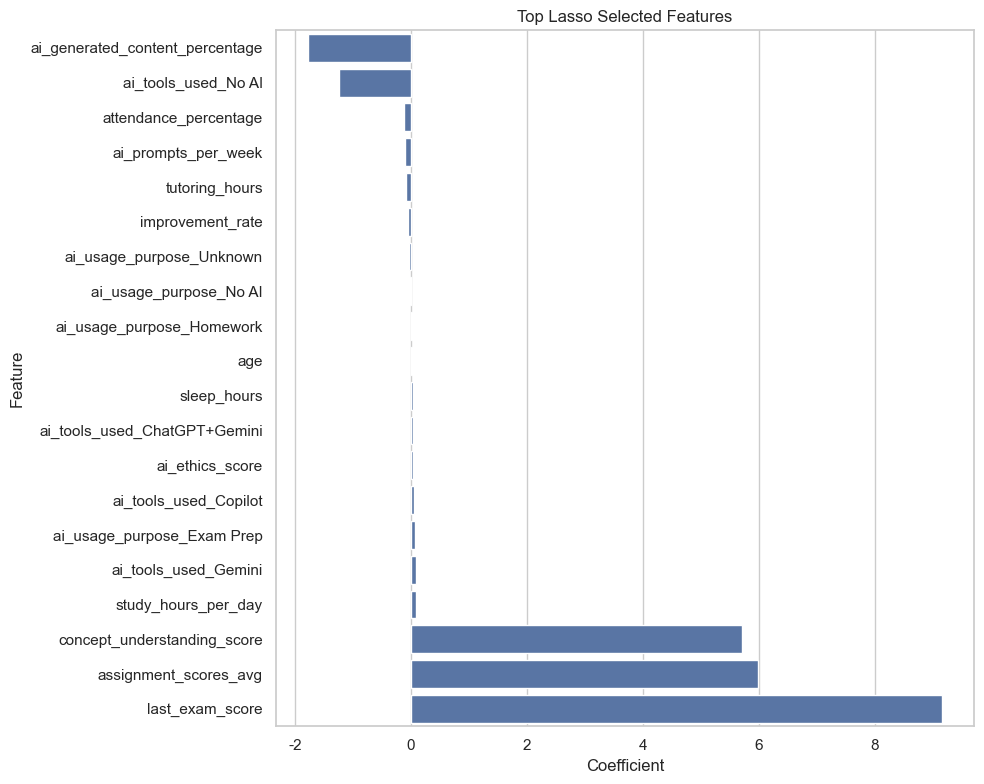

In [47]:

# -----------------------------
# 11.2 Lasso coefficient plot | Lasso 关键系数图
# -----------------------------

top_lasso = selected_features.head(20).sort_values()

plt.figure(figsize=(10, 8))
sns.barplot(x=top_lasso.values, y=top_lasso.index, color="C0")
plt.title("Top Lasso Selected Features")#Lasso 筛选出的关键特征
plt.xlabel("Coefficient")#系数
plt.ylabel("Feature")#特征
plt.tight_layout()
plt.show()


### Key patterns to discuss | 重点讨论的结论方向
1. Traditional learning factors such as attendance, concept understanding, and study consistency are expected to remain strong predictors of performance.  
   出勤率、概念理解度、学习一致性等传统学习变量通常仍然是成绩的重要预测因素。
2. AI usage itself may not be the main issue; dependency and substitution-oriented usage are more important.  
   AI 使用本身未必是问题核心，更值得关注的是依赖程度以及替代性使用方式。
3. The at-risk model can support early-warning intervention for education managers.  
   高风险识别模型可以为教育管理者提供早期预警支持。
4. Lasso helps narrow managerial focus to a smaller set of high-impact indicators.  
   Lasso 可以帮助管理层把注意力集中在少数高影响指标上。

### Suggested report phrasing | 报告写作建议
> AI is not inherently beneficial or harmful; its impact depends on how it is integrated into students' learning behavior.  
> AI 并非天然有益或有害，其影响取决于它是如何被整合进学生学习过程中的。
